# Prepare the GSE175385 external validation dataset

**Biology rationale.** Independent cohorts test whether the plasma-cell programs discovered in the primary AL cohort are reproducible.

**Aim.** Load and standardize the public Seurat object for downstream validation analyses.

**Data input.** `GSE175385_Seurat_object.Rdata`, `GSE175385_Seurat_object.RData`



**Data outputs.** Processed objects, statistical summaries, and visualizations generated in the notebook.

## 1. Setup


In [1]:
# ================================
# 0) Setup
# ================================
suppressPackageStartupMessages({
  library(Seurat)
  library(dplyr)
  library(ggplot2)
})

options(repr.plot.width = 8, repr.plot.height = 6)


## 2. Define the unzipped file path

Edit `file_path` if your file is in another folder. Do **not** use `gzfile()` for the unzipped file.


In [2]:
# ================================
# 1) File path
# ================================
file_path <- "GSE175385_Seurat_object.Rdata"

# If your file has capital D, uncomment this line:
# file_path <- "GSE175385_Seurat_object.RData"

stopifnot(file.exists(file_path))
file.info(file_path)


,size,isdir,mode,mtime,ctime,atime,uid,gid,uname,grname
,<dbl>,<lgl>,<octmode>,<dttm>,<dttm>,<dttm>,<int>,<int>,<chr>,<chr>


## 3. Load the `.Rdata` file into a clean environment

Using a separate environment avoids accidentally overwriting variables in your notebook.


In [3]:
# ================================
# 2) Load RData
# ================================
rdata_env <- new.env(parent = emptyenv())
loaded_names <- load(file_path, envir = rdata_env)

cat("Loaded objects:\n")
print(loaded_names)


Loaded objects:
[1] "super.merge_NKandBremove"


## 4. Inspect loaded objects and identify the Seurat object


In [4]:
# ================================
# 3) Inspect object classes
# ================================
obj_summary <- data.frame(
  object_name = loaded_names,
  class = sapply(loaded_names, function(nm) paste(class(rdata_env[[nm]]), collapse = "; ")),
  stringsAsFactors = FALSE
)

obj_summary


,object_name,class
,<chr>,<chr>
super.merge_NKandBremove,super.merge_NKandBremove,Seurat


In [5]:
# Automatically find Seurat object(s)
seurat_names <- loaded_names[sapply(loaded_names, function(nm) inherits(rdata_env[[nm]], "Seurat"))]

if (length(seurat_names) == 0) {
  stop("No Seurat object found in this .Rdata file. Check obj_summary above.")
}

cat("Detected Seurat object(s):\n")
print(seurat_names)

# Use the first detected Seurat object by default
obj_name <- seurat_names[1]
obj <- rdata_env[[obj_name]]

cat("Using object:", obj_name, "\n")
obj


Detected Seurat object(s):
[1] "super.merge_NKandBremove"
Using object: super.merge_NKandBremove 


An object of class Seurat 
48672 features across 142778 samples within 2 assays 
Active assay: SCT (22329 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 2 dimensional reductions calculated: pca, umap

## 5. Basic Seurat object information


In [6]:
# ================================
# 4) Basic QC / structure
# ================================
cat("Number of genes/features x cells:\n")
print(dim(obj))

cat("\nAssays:\n")
print(Assays(obj))

cat("\nDefault assay:\n")
print(DefaultAssay(obj))

cat("\nReductions:\n")
print(Reductions(obj))

cat("\nMetadata columns:\n")
print(colnames(obj@meta.data))

head(obj@meta.data)


Number of genes/features x cells:
[1]  22329 142778

Assays:
[1] "RNA" "SCT"

Default assay:
[1] "SCT"

Reductions:
[1] "pca"  "umap"

Metadata columns:
 [1] "orig.ident"      "nCount_RNA"      "nFeature_RNA"    "origin"         
 [5] "percent.mt"      "nCount_SCT"      "nFeature_SCT"    "SCT_snn_res.0.5"
 [9] "seurat_clusters" "TP11"            "TP21"            "TP31"           
[13] "TP41"            "TP51"            "TP61"            "TP71"           
[17] "TP81"            "TP91"            "TP101"           "TP111"          
[21] "TP121"           "TP131"           "TP_Max"          "TP_Max_T"       
[25] "S.Score"         "G2M.Score"       "Phase"           "old.ident"      


,orig.ident,nCount_RNA,nFeature_RNA,origin,percent.mt,nCount_SCT,nFeature_SCT,SCT_snn_res.0.5,seurat_clusters,TP11,⋯,TP101,TP111,TP121,TP131,TP_Max,TP_Max_T,S.Score,G2M.Score,Phase,old.ident
,<chr>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<int>,<fct>,<fct>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<fct>
HR_2_AAACCTGAGTCGTACT,HR,9338,1213,MM4,1.799100,7946,1205,23,23,0.10289908,⋯,0.06768928,0.3207104,0.2534889,0.1363823,TP8,TP12,-0.003214055,-0.0404417848,G1,TP12
HR_2_AAACCTGCACCCTATC,HR,9913,1469,MM4,3.006154,8048,1459,23,23,0.18727226,⋯,0.07909411,0.3126621,0.2765535,0.1997551,TP8,TP12,0.007805555,-0.0398690853,S,TP12
HR_2_AAACCTGCATCACCCT,HR,5225,1119,MM4,2.028708,7550,1108,23,23,0.16244020,⋯,0.03261045,0.3146304,0.2527937,0.1475499,TP8,TP12,-0.008083476,-0.0230332691,G1,TP12
HR_2_AAACCTGGTCTGCCAG,HR,8584,1249,MM4,1.887232,7933,1244,23,23,0.19629109,⋯,0.08558154,0.3011260,0.2682942,0.1593849,TP8,TP12,-0.017973342,-0.0442846154,G1,TP12
HR_2_AAACGGGGTCGAGTTT,HR,5328,1106,MM4,2.796547,7481,1097,23,23,0.08540411,⋯,0.05653533,0.2808380,0.2965079,0.1424341,TP8,TP12,-0.025598691,-0.0004265499,G1,TP12
HR_2_AAACGGGTCGCCAAAT,HR,13699,1821,MM4,2.343237,8175,1770,23,23,0.13228970,⋯,0.09995655,0.2642929,0.3428666,0.1620940,TP8,TP12,-0.020968904,-0.0327316064,G1,TP12


## 6. Sample metadata and clinical groups

This helps identify useful columns for `group.by`, such as cell type, sample, patient, disease, treatment, or cluster labels.


In [7]:
# ================================
# 5) Metadata overview
# ================================
meta <- obj@meta.data

meta_overview <- data.frame(
  column = colnames(meta),
  class = sapply(meta, function(x) paste(class(x), collapse = "; ")),
  n_unique = sapply(meta, function(x) length(unique(x))),
  n_missing = sapply(meta, function(x) sum(is.na(x))),
  stringsAsFactors = FALSE
)

meta_overview %>% arrange(n_unique)


,column,class,n_unique,n_missing
,<chr>,<chr>,<int>,<int>
Phase,Phase,character,3,0
orig.ident,orig.ident,character,10,0
TP_Max,TP_Max,character,12,0
TP_Max_T,TP_Max_T,character,13,0
old.ident,old.ident,factor,13,0
SCT_snn_res.0.5,SCT_snn_res.0.5,factor,24,0
seurat_clusters,seurat_clusters,factor,24,0
origin,origin,character,30,0
nFeature_SCT,nFeature_SCT,integer,3446,0


## 7. UMAP visualization if available

Change `group_col` to a metadata column that exists in your object.


Selected group_col: seurat_clusters 


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



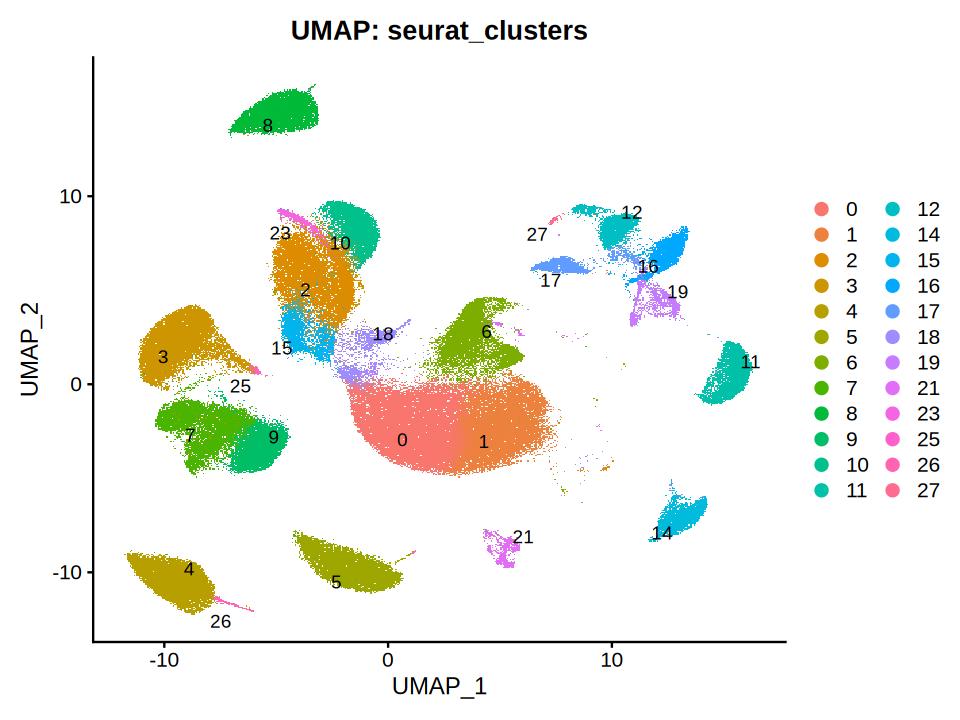

In [8]:
# ================================
# 6) UMAP visualization
# ================================
reductions_available <- Reductions(obj)

# Choose a grouping column automatically if possible
candidate_group_cols <- c(
  "celltype", "cell_type", "CellType", "cell.types",
  "annotation", "Annotation", "seurat_clusters",
  "orig.ident", "sample", "Sample", "patient", "Patient"
)
group_col <- candidate_group_cols[candidate_group_cols %in% colnames(obj@meta.data)][1]

if (is.na(group_col)) {
  group_col <- NULL
}

cat("Selected group_col:", ifelse(is.null(group_col), "None", group_col), "\n")

if ("umap" %in% reductions_available) {
  p <- DimPlot(obj, reduction = "umap", group.by = group_col, label = TRUE, repel = TRUE) +
    ggtitle(paste0("UMAP: ", ifelse(is.null(group_col), "default identities", group_col)))
  print(p)
} else {
  message("No UMAP reduction found. Available reductions: ", paste(reductions_available, collapse = ", "))
}


## 8. Feature plot / violin plot for selected marker genes

Edit `genes_to_plot` based on your question. The code automatically keeps genes present in the object.


Genes present:
[1] "CD3D"  "CD8A"  "MS4A1" "LYZ"   "NKG7"  "MKI67"


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To di

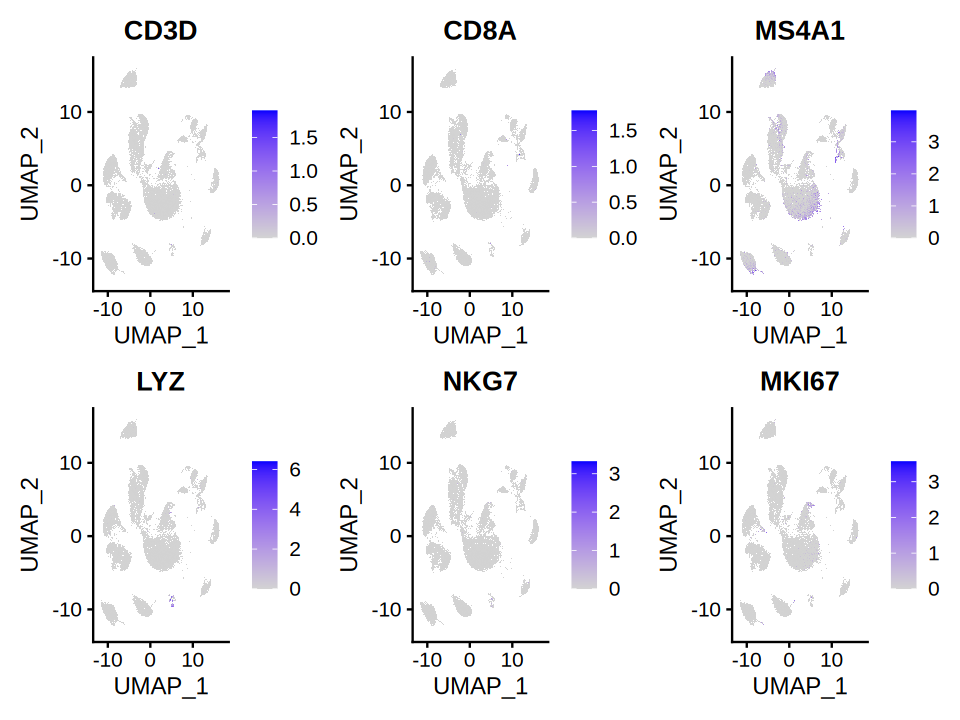

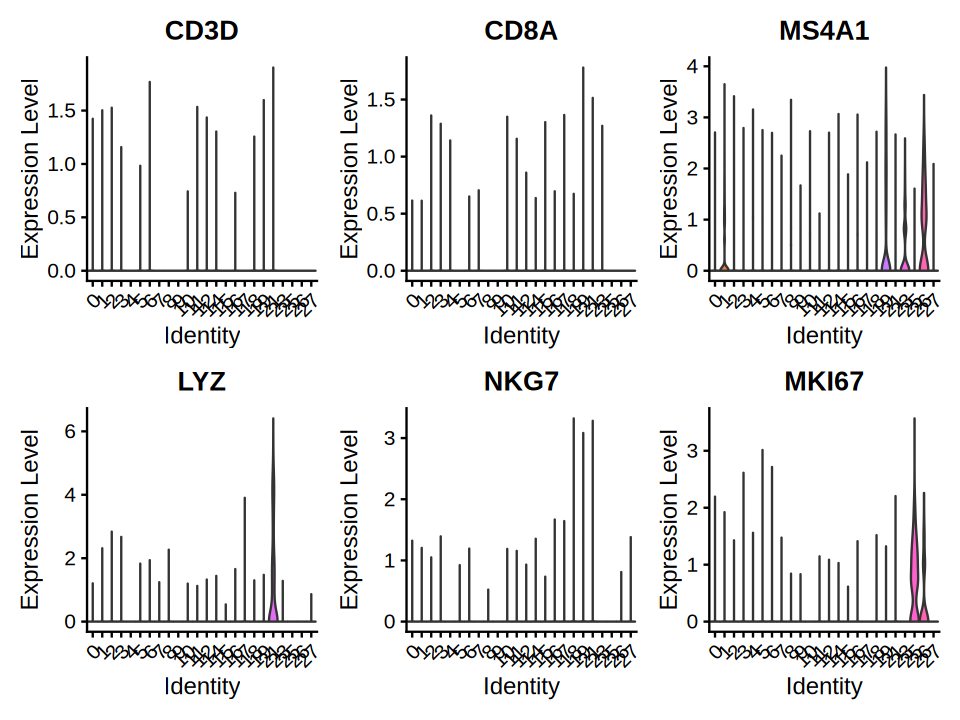

In [9]:
# ================================
# 7) Marker visualization
# ================================
genes_to_plot <- c("CD3D", "CD8A", "MS4A1", "LYZ", "NKG7", "MKI67")
genes_present <- genes_to_plot[genes_to_plot %in% rownames(obj)]

cat("Genes present:\n")
print(genes_present)

if (length(genes_present) > 0) {
  if ("umap" %in% Reductions(obj)) {
    print(FeaturePlot(obj, features = genes_present, reduction = "umap", ncol = 3))
  }
  print(VlnPlot(obj, features = genes_present, group.by = group_col, pt.size = 0, ncol = 3))
} else {
  message("None of the selected marker genes were found in rownames(obj).")
}


## 9. Save as `.rds` for easier future loading

After this, you can load the object with `readRDS()` instead of `load()`.


In [10]:
# ================================
# 8) Save RDS
# ================================
out_rds <- sub("\\.RData$|\\.Rdata$|\\.rda$|\\.RDA$", ".rds", basename(file_path), ignore.case = TRUE)
saveRDS(obj, file = out_rds)
cat("Saved Seurat object to:", out_rds, "\n")


Saved Seurat object to: GSE175385_Seurat_object.rds 


## 10. Reload test


In [11]:
# Confirm the saved RDS can be reloaded
obj_test <- readRDS(out_rds)
obj_test


An object of class Seurat 
48672 features across 142778 samples within 2 assays 
Active assay: SCT (22329 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 2 dimensional reductions calculated: pca, umap